# 05 — Gaze Variability

Quantifies how much and how erratically the subject's eyes move. The trust literature links gaze patterns to perceived engagement, attentiveness, and calm — high variability (fidgety, scanning eyes) has been associated with lower perceived trustworthiness in some contexts, while moderate variability is typical of engaged conversation.

This notebook computes:
- **Iris-offset std** (per axis) — the amount of spread in gaze position.
- **Fixations and saccades** via the **I-VT** (velocity-threshold) algorithm.
- **Saccade rate** (saccades per minute) and **mean fixation duration**.

**Input:** `data/<video>_merged.parquet` from `00_pipeline.ipynb`.  
**Outputs:** summary stats table, time-series plot with fixations shaded, per-frame classification parquet.

---

### ⚠ Read this first — temporal-resolution caveat

Real human saccades last **20–100 ms**. At our effective sampling rate of ~6 fps (one frame every ~167 ms) **individual saccades cannot be resolved** — a single-frame "saccade" in our data actually conflates a real saccade with some fixation time around it. Treat the fixation/saccade numbers as *coarse activity indicators*, not precise oculomotor measurements. For rigorous saccade analysis you need a high-frame-rate webcam recording (60+ fps) and a lower `SKIP_FRAMES` in the pipeline, or — ideally — an actual eye tracker.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)

## Config

- `VELOCITY_THRESHOLD` — I-VT threshold in **eye-widths per second**. Frames with gaze velocity above this count as saccades; below, as fixations. Default 30 per the ticket spec; tune based on the velocity histogram below.
- `MIN_FIXATION_MS` — minimum fixation duration in ms. Shorter runs of below-threshold frames are discarded as noise.
- `MIN_SACCADE_FRAMES` — a saccade must span at least this many frames. At 6 fps, 1 frame = 167 ms, so 1 is the minimum; raise to 2 to be more conservative.

In [2]:
VIDEO_STEM = "sample"

VELOCITY_THRESHOLD = 30.0   # eye-widths per second
MIN_FIXATION_MS = 100       # fixations shorter than this are discarded
MIN_SACCADE_FRAMES = 1      # minimum frames a saccade must span

PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PARQUET_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.parquet"
META_PATH = DATA_DIR / f"{VIDEO_STEM}_merged.meta.json"
OUT_PATH = DATA_DIR / f"{VIDEO_STEM}_gaze_variability.parquet"

print("Input :", PARQUET_PATH)
print("Output:", OUT_PATH)

Input : /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_merged.parquet
Output: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_gaze_variability.parquet


In [3]:
df = pd.read_parquet(PARQUET_PATH)
meta = pd.read_json(META_PATH, typ="series")
FPS = float(meta["effective_fps"])
frame_duration_s = 1.0 / FPS
print(f"{len(df)} sampled frames, effective fps = {FPS:.2f}")

165 sampled frames, effective fps = 6.00


## 1. Compute iris offsets (same formula as Ticket 3)

**What:** per-frame `offset_x` and `offset_y` in **eye-widths** (normalized by eye geometry, so scale-invariant). See `metrics/03_eye_contact.ipynb` Section 1 for the derivation.

**Sign:** both eyes flipped to a shared convention — `offset_x > 0` means looking toward the subject's right. Averaged over both eyes to reduce landmark noise.

In [4]:
def eye_offset(df, side: str):
    iris_x = df[f"mp_face_{side}_iris_x"]
    iris_y = df[f"mp_face_{side}_iris_y"]
    outer_x = df[f"mp_face_{side}_eye_outer_x"]
    inner_x = df[f"mp_face_{side}_eye_inner_x"]
    top_y = df[f"mp_face_{side}_eye_top_y"]
    bot_y = df[f"mp_face_{side}_eye_bot_y"]
    mid_x = (outer_x + inner_x) / 2
    mid_y = (top_y + bot_y) / 2
    eye_w = (outer_x - inner_x).abs()
    eye_h = (top_y - bot_y).abs()
    off_x = (iris_x - mid_x) / eye_w
    off_y = (iris_y - mid_y) / eye_h
    if side == "l":
        off_x = -off_x
    return off_x, off_y

lx, ly = eye_offset(df, "l")
rx, ry = eye_offset(df, "r")
gaze = df[["frame", "timestamp"]].copy()
gaze["offset_x"] = pd.concat([lx, rx], axis=1).mean(axis=1)
gaze["offset_y"] = pd.concat([ly, ry], axis=1).mean(axis=1)
gaze = gaze.dropna(subset=["offset_x", "offset_y"]).reset_index(drop=True)
print(gaze[["offset_x", "offset_y"]].describe().round(3))

       offset_x  offset_y
count   165.000   165.000
mean      0.040    -0.090
std       0.007     0.044
min       0.004    -0.341
25%       0.037    -0.107
50%       0.041    -0.085
75%       0.045    -0.058
max       0.060    -0.005


## 2. Offset standard deviation

**What this section does:** reports the overall spread of gaze positions — both as a single global std per axis, and as a rolling 2-second std to show variability over time.

**Interpretation:**
- High `offset_x_std` → the subject looked left and right a lot.
- High `offset_y_std` → the subject looked up and down a lot.
- Low std on both → gaze was mostly held steady (likely a single fixation target — could be the camera, a screen, or a prepared-speech focus).

These are *amount* measures; fixation/saccade counts in the next section are *structure* measures. High std with few saccades means slow gaze drift; high std with many saccades means active scanning.

In [5]:
W = max(2, int(round(2.0 * FPS)))
rs = gaze[["offset_x", "offset_y"]].rolling(W, center=True, min_periods=max(2, W // 2)).std()
gaze["offset_x_std2s"] = rs["offset_x"]
gaze["offset_y_std2s"] = rs["offset_y"]

print("global std:")
print(gaze[["offset_x", "offset_y"]].std().round(4))
print("\nrolling 2s std (mean / max):")
print(gaze[["offset_x_std2s", "offset_y_std2s"]].agg(["mean", "max"]).round(4))

global std:
offset_x    0.0074
offset_y    0.0436
dtype: float64

rolling 2s std (mean / max):
      offset_x_std2s  offset_y_std2s
mean          0.0063          0.0323
max           0.0135          0.0930


## 3. Velocity and I-VT classification

**What the I-VT algorithm does:** labels each frame as either "fixation" (eyes roughly still) or "saccade" (eyes moving fast) based on a single threshold on gaze velocity.

**Velocity formula** (2D, per frame):
$$v_t = \frac{\sqrt{(\Delta x_t)^2 + (\Delta y_t)^2}}{\Delta t}$$

where `Δx_t = offset_x[t] − offset_x[t−1]` and `Δt = 1/FPS`. Units: eye-widths per second.

**Classification:**
- `velocity < VELOCITY_THRESHOLD` → **fixation** sample.
- `velocity ≥ VELOCITY_THRESHOLD` → **saccade** sample.

**Why velocity-based (not position-based):** a subject holding gaze steady at an off-center position should still count as one fixation, not as "off target." Velocity captures motion, not location.

**Post-processing:**
- Runs of consecutive fixation samples become single fixation events.
- Fixations shorter than `MIN_FIXATION_MS` are discarded as noise (real fixations are ≥100 ms).
- Saccades shorter than `MIN_SACCADE_FRAMES` frames are ignored — at 6 fps, single-frame saccades still count by default because that's the best resolution we have.

**Tuning the threshold:** inspect the velocity histogram cell below. A well-chosen threshold falls in a valley between low-velocity fixation samples and high-velocity saccade samples. If there's no clear valley, the threshold matters less — the temporal resolution caveat at the top of this notebook dominates.

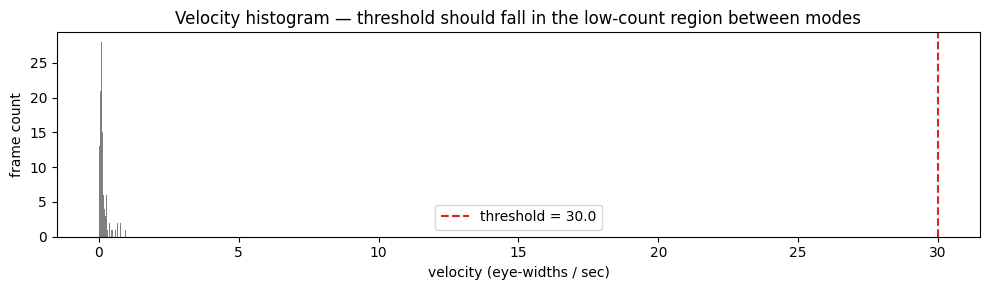

In [6]:
dx = gaze["offset_x"].diff()
dy = gaze["offset_y"].diff()
gaze["velocity"] = np.sqrt(dx * dx + dy * dy) / frame_duration_s
gaze["velocity"] = gaze["velocity"].fillna(0.0)  # first frame has no prior

gaze["is_saccade"] = gaze["velocity"] >= VELOCITY_THRESHOLD
gaze["is_fixation"] = ~gaze["is_saccade"]

# Velocity histogram for threshold tuning
fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(gaze["velocity"].clip(upper=gaze["velocity"].quantile(0.99)), bins=40, color="tab:gray")
ax.axvline(VELOCITY_THRESHOLD, color="tab:red", ls="--", label=f"threshold = {VELOCITY_THRESHOLD}")
ax.set_xlabel("velocity (eye-widths / sec)")
ax.set_ylabel("frame count")
ax.set_title("Velocity histogram — threshold should fall in the low-count region between modes")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# Detect contiguous runs of fixation / saccade samples.
def find_runs(mask: np.ndarray):
    mask = np.asarray(mask).astype(bool)
    if mask.size == 0:
        return []
    diff = np.diff(mask.astype(int), prepend=0, append=0)
    starts = np.where(diff == 1)[0]
    ends = np.where(diff == -1)[0] - 1
    return list(zip(starts.tolist(), ends.tolist()))

fix_runs = find_runs(gaze["is_fixation"].to_numpy())
sac_runs = find_runs(gaze["is_saccade"].to_numpy())

ts = gaze["timestamp"].to_numpy()
def run_duration(s, e):
    return float(ts[e] - ts[s] + frame_duration_s)

fixations = [(s, e, run_duration(s, e)) for s, e in fix_runs]
fixations = [f for f in fixations if f[2] * 1000 >= MIN_FIXATION_MS]
saccades = [(s, e, run_duration(s, e)) for s, e in sac_runs if (e - s + 1) >= MIN_SACCADE_FRAMES]

print(f"raw fixation runs: {len(fix_runs)} -> kept after min-duration filter: {len(fixations)}")
print(f"raw saccade runs:  {len(sac_runs)} -> kept after min-frames filter:   {len(saccades)}")

raw fixation runs: 1 -> kept after min-duration filter: 1
raw saccade runs:  0 -> kept after min-frames filter:   0


## 4. Summary stats

The headline numbers you'd report for a single video.

**What each number means:**
- `offset_x_std` / `offset_y_std` — global spread of gaze on each axis. Eye-widths.
- `n_fixations` / `n_saccades` — event counts.
- `mean_fixation_s` — average fixation duration. Typical conversational fixations are 200–400 ms; longer fixations indicate sustained attention, shorter indicates scanning.
- `saccades_per_minute` — event-rate. For natural conversation, roughly 60–180/min on an eye tracker; at 6 fps we substantially undercount fast saccades, so treat this as a lower bound.
- `pct_time_fixating` — share of analyzed time classified as fixation.

In [8]:
dur_total_s = len(gaze) * frame_duration_s
fix_time_s = sum(f[2] for f in fixations)
n_sacc = len(saccades)
mean_fix = np.mean([f[2] for f in fixations]) if fixations else float("nan")

summary = pd.Series({
    "duration_s": round(dur_total_s, 2),
    "offset_x_std": round(float(gaze["offset_x"].std()), 4),
    "offset_y_std": round(float(gaze["offset_y"].std()), 4),
    "n_fixations": len(fixations),
    "n_saccades": n_sacc,
    "mean_fixation_s": round(float(mean_fix), 3) if not np.isnan(mean_fix) else float("nan"),
    "saccades_per_minute": round(60 * n_sacc / dur_total_s, 1) if dur_total_s else float("nan"),
    "pct_time_fixating": round(100 * fix_time_s / dur_total_s, 1) if dur_total_s else float("nan"),
    "velocity_threshold": VELOCITY_THRESHOLD,
})
summary

duration_s              27.5000
offset_x_std             0.0074
offset_y_std             0.0436
n_fixations              1.0000
n_saccades               0.0000
mean_fixation_s         27.5000
saccades_per_minute      0.0000
pct_time_fixating      100.0000
velocity_threshold      30.0000
dtype: float64

## 5. Time-series plot with fixations shaded

**What this chart shows:**
- Top: offset_x and offset_y over time.
- Middle: gaze velocity over time, with the threshold line.
- Bottom: fixation/saccade strip (green = fixation, red = saccade).
- Green shading across all panels = detected fixation event (post-filter).

**How to read it:** fixation regions should line up with flat stretches in the top panel and below-threshold stretches in the middle panel. Mismatch means either the threshold needs tuning or the filter is too aggressive.

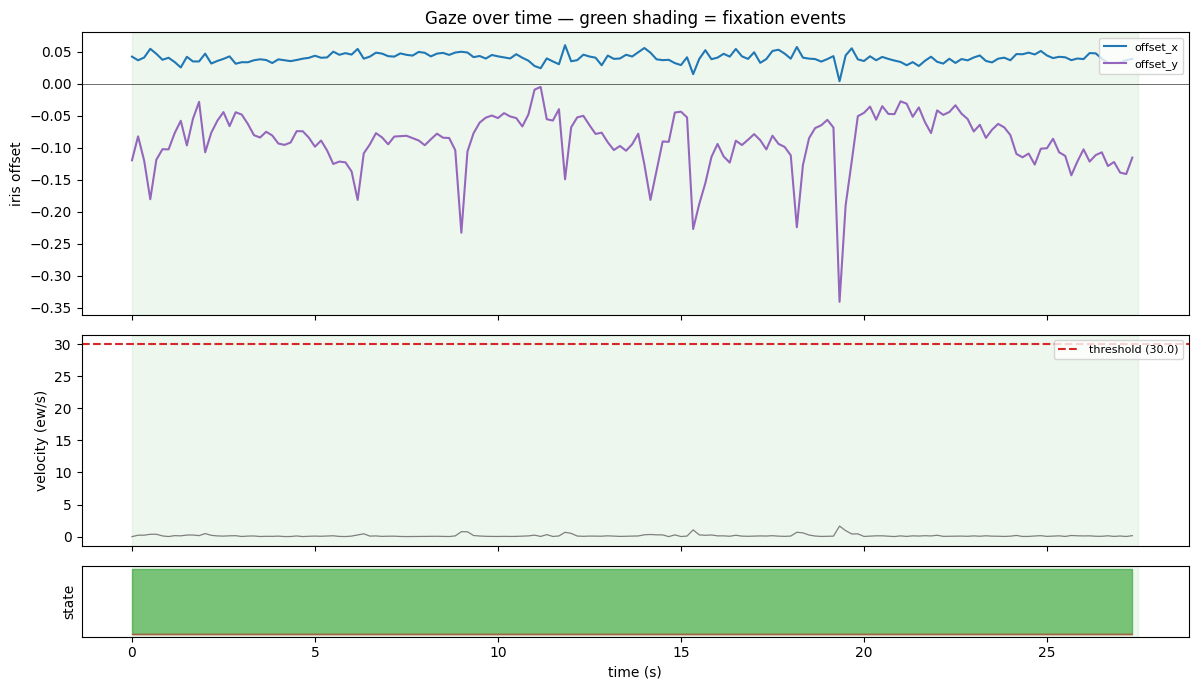

In [9]:
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True,
                         gridspec_kw={"height_ratios": [2, 1.5, 0.5]})
t = gaze["timestamp"].to_numpy()

axes[0].plot(t, gaze["offset_x"], color="tab:blue", label="offset_x")
axes[0].plot(t, gaze["offset_y"], color="tab:purple", label="offset_y")
axes[0].axhline(0, color="k", lw=0.4)
axes[0].set_ylabel("iris offset")
axes[0].legend(loc="upper right", fontsize=8)
axes[0].set_title("Gaze over time — green shading = fixation events")

axes[1].plot(t, gaze["velocity"], color="tab:gray", lw=0.9)
axes[1].axhline(VELOCITY_THRESHOLD, color="tab:red", ls="--", label=f"threshold ({VELOCITY_THRESHOLD})")
axes[1].set_ylabel("velocity (ew/s)")
axes[1].legend(loc="upper right", fontsize=8)

axes[2].fill_between(t, 0, gaze["is_fixation"].astype(int), color="tab:green", step="mid", alpha=0.6)
axes[2].fill_between(t, 0, gaze["is_saccade"].astype(int), color="tab:red", step="mid", alpha=0.6)
axes[2].set_yticks([])
axes[2].set_xlabel("time (s)")
axes[2].set_ylabel("state")

for s, e, _ in fixations:
    span_start = ts[s]
    span_end = ts[e] + frame_duration_s
    for ax in axes:
        ax.axvspan(span_start, span_end, color="tab:green", alpha=0.08)

plt.tight_layout()
plt.show()

## 6. Save per-frame classification for reuse

In [10]:
out = gaze[["frame", "timestamp", "offset_x", "offset_y", "velocity", "is_fixation", "is_saccade"]].copy()
out.to_parquet(OUT_PATH, index=False)
print(f"Saved: {OUT_PATH}  ({len(out)} rows, {int(out['is_fixation'].sum())} fixation frames, {int(out['is_saccade'].sum())} saccade frames)")

Saved: /Users/atharvumap/Documents/Projects/PyfeatTesting/data/sample_gaze_variability.parquet  (165 rows, 165 fixation frames, 0 saccade frames)
